# Model Development

## Objective

The objective of this notebook is to train and evaluate the first machine learning model for predicting customer churn using the preprocessed dataset.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [2]:
train_df = pd.read_csv("../data/processed/train_processed.csv")
test_df = pd.read_csv("../data/processed/test_processed.csv")

print("Training Dataset:", train_df.shape)
print("Testing Dataset :", test_df.shape)

Training Dataset: (5634, 48)
Testing Dataset : (1409, 48)


## Defining Features and Target

The processed datasets are separated into input features and the target variable before training the machine learning model.

In [3]:
X_train = train_df.drop("Churn Value", axis=1)
y_train = train_df["Churn Value"]

X_test = test_df.drop("Churn Value", axis=1)
y_test = test_df["Churn Value"]

print("Training Features :", X_train.shape)
print("Training Target   :", y_train.shape)

print("Testing Features  :", X_test.shape)
print("Testing Target    :", y_test.shape)

Training Features : (5634, 47)
Training Target   : (5634,)
Testing Features  : (1409, 47)
Testing Target    : (1409,)


## Logistic Regression Model

Logistic Regression is selected as the baseline classification algorithm. It is a simple, efficient, and interpretable model commonly used for binary classification problems such as customer churn prediction.

In [4]:
model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

## Training the Model

The Logistic Regression model is trained using the processed training dataset.

In [5]:
model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


c:\Users\ASUS\OneDrive\Masaüstü\Telecom-Customer-Retention-Intelligence-Platform\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Making Predictions

After training, the Logistic Regression model is used to predict customer churn on the testing dataset.

In [6]:
y_pred = model.predict(X_test)

print("Number of predictions:", len(y_pred))
print(y_pred[:10])

Number of predictions: 1409
[0 1 0 0 0 1 0 0 0 0]


## Model Evaluation

The Logistic Regression model is evaluated using accuracy, precision, recall, and F1 score. These metrics provide a broader assessment of model performance, especially for the churn class.

In [7]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.8062
Precision: 0.6517
Recall   : 0.5802
F1 Score : 0.6139


## Classification Report

A detailed classification report is generated to evaluate the model's performance for each class separately.

In [8]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.58      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



## Confusion Matrix

The confusion matrix provides a detailed breakdown of correct and incorrect predictions, allowing us to identify how many churn and non-churn customers are classified correctly.

In [9]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[919 116]
 [157 217]]


## Confusion Matrix Visualization

The confusion matrix is visualized to better understand the distribution of correct and incorrect predictions.

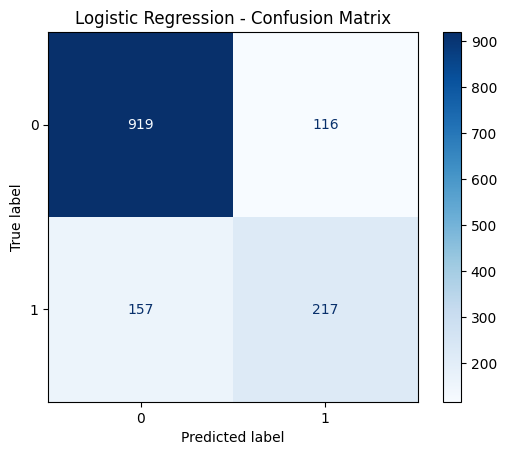

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

### Interpretation

The Logistic Regression model correctly classified **919 non-churn customers** and **217 churn customers**.

However, the model incorrectly predicted **116 non-churn customers** as churn (False Positives) and failed to identify **157 actual churn customers** (False Negatives).

Although the overall accuracy is satisfactory, the number of false negatives indicates that the model still misses a considerable portion of customers who are actually at risk of leaving. Reducing false negatives will be one of the main objectives when evaluating more advanced models such as Decision Tree, Random Forest, and XGBoost.

## ROC Curve and AUC Score

The Receiver Operating Characteristic (ROC) curve illustrates the trade-off between the True Positive Rate and False Positive Rate across different classification thresholds.

The Area Under the Curve (AUC) summarizes the model's overall ability to distinguish between churn and non-churn customers.

AUC Score: 0.8493


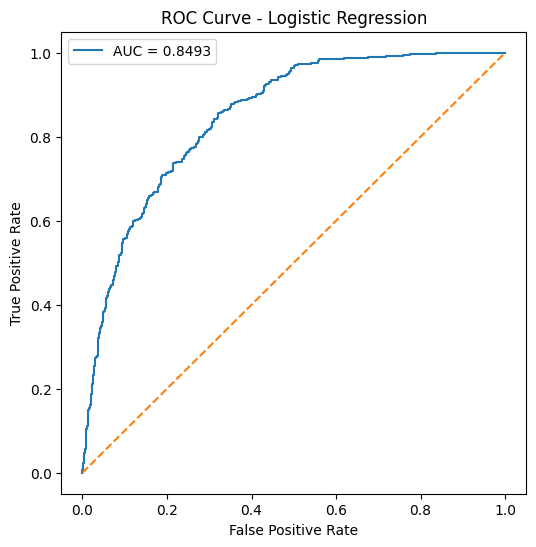

In [11]:
y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

print(f"AUC Score: {auc:.4f}")

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.show()

## Logistic Regression Summary

The Logistic Regression model achieved an overall accuracy of **80.62%** and an AUC score of **0.8493**, indicating a good ability to distinguish between churn and non-churn customers.

Although the model performed well for the majority class, its recall for churn customers (58.02%) suggests that a significant number of customers at risk of leaving were not identified.

Therefore, Logistic Regression will serve as the **baseline model**, and its performance will be compared with more advanced machine learning algorithms in the following sections.

# Decision Tree Classifier

## Objective

A Decision Tree model is trained and evaluated to capture non-linear relationships in customer churn behavior. Its performance will be compared with the Logistic Regression baseline model.

In [12]:
from sklearn.tree import DecisionTreeClassifier

## Model Initialization

The Decision Tree classifier is initialized with a fixed random state to ensure reproducibility of the results.

In [13]:
decision_tree = DecisionTreeClassifier(
    random_state=42
)

print(decision_tree)

DecisionTreeClassifier(random_state=42)


## Model Training

The Decision Tree model is trained using the processed training dataset. During this step, the algorithm learns decision rules that separate churn and non-churn customers.

In [14]:
decision_tree.fit(X_train, y_train)

print("Decision Tree training completed successfully!")

Decision Tree training completed successfully!


## Making Predictions

The trained Decision Tree model is used to predict customer churn on the testing dataset.

In [15]:
y_pred_tree = decision_tree.predict(X_test)

print("Number of predictions:", len(y_pred_tree))
print(y_pred_tree[:10])

Number of predictions: 1409
[0 1 0 1 0 1 1 0 0 1]


## Model Evaluation

The Decision Tree model is evaluated using standard classification metrics, including accuracy, precision, recall, and F1 score.

In [16]:
accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)

print(f"Accuracy : {accuracy_tree:.4f}")
print(f"Precision: {precision_tree:.4f}")
print(f"Recall   : {recall_tree:.4f}")
print(f"F1 Score : {f1_tree:.4f}")

Accuracy : 0.7211
Precision: 0.4757
Recall   : 0.4973
F1 Score : 0.4863


## Classification Report

A detailed classification report is generated to evaluate the Decision Tree model for each class separately.

In [17]:
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.82      0.80      0.81      1035
           1       0.48      0.50      0.49       374

    accuracy                           0.72      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.73      0.72      0.72      1409



## Confusion Matrix

The confusion matrix summarizes the number of correct and incorrect predictions made by the Decision Tree model.

In [18]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

print(cm_tree)

[[830 205]
 [188 186]]


## Confusion Matrix Visualization

The confusion matrix is visualized to better understand the distribution of correct and incorrect predictions made by the Decision Tree model.

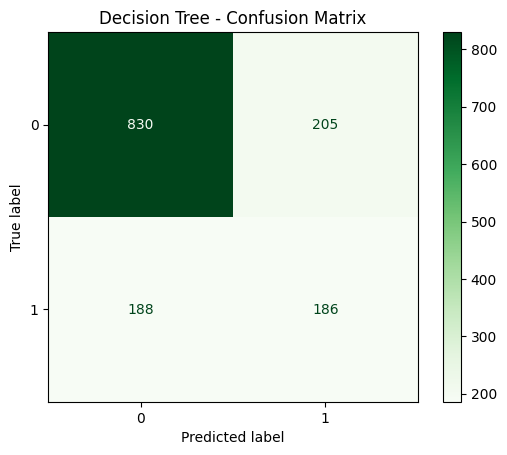

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    decision_tree,
    X_test,
    y_test,
    cmap="Greens"
)

plt.title("Decision Tree - Confusion Matrix")
plt.show()

### Interpretation

The Decision Tree model correctly classified **830 non-churn customers** and **186 churn customers**.

However, the model incorrectly classified **205 non-churn customers** as churn (False Positives) and failed to identify **188 actual churn customers** (False Negatives).

Compared with the Logistic Regression model, the Decision Tree produced more false positives and false negatives, resulting in lower overall performance. This suggests that the default Decision Tree model is not the most suitable choice for this dataset without further tuning.

## ROC Curve and AUC Score

The ROC curve illustrates the Decision Tree model's ability to distinguish between churn and non-churn customers across different classification thresholds.

The Area Under the Curve (AUC) summarizes the overall discriminative performance of the model.

AUC Score: 0.6496


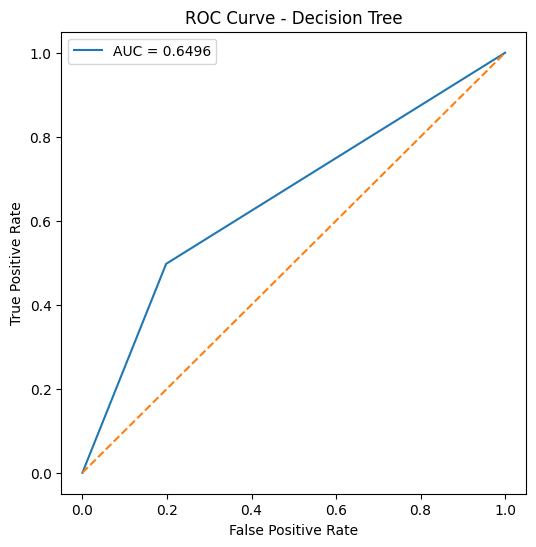

In [20]:
y_prob_tree = decision_tree.predict_proba(X_test)[:, 1]

fpr_tree, tpr_tree, thresholds_tree = roc_curve(y_test, y_prob_tree)

auc_tree = roc_auc_score(y_test, y_prob_tree)

print(f"AUC Score: {auc_tree:.4f}")

plt.figure(figsize=(6,6))

plt.plot(
    fpr_tree,
    tpr_tree,
    label=f"AUC = {auc_tree:.4f}"
)

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")

plt.legend()

plt.show()

## Overfitting Check

The training and testing accuracies are compared to determine whether the Decision Tree model has overfitted the training data.

In [21]:
train_predictions = decision_tree.predict(X_train)

train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy = accuracy_score(y_test, y_pred_tree)

print(f"Training Accuracy : {train_accuracy:.4f}")
print(f"Testing Accuracy  : {test_accuracy:.4f}")

Training Accuracy : 1.0000
Testing Accuracy  : 0.7211


## Overfitting Analysis

The Decision Tree achieved **100% training accuracy**, while its testing accuracy dropped to **72.11%**.

This large performance gap indicates that the model has **overfitted** the training data. The tree has memorized the training samples instead of learning general decision patterns that can be applied to unseen customers.

To improve generalization performance, the tree depth and other complexity-related hyperparameters will be tuned in future experiments.

## Decision Tree Summary

The Decision Tree model achieved a testing accuracy of **72.11%** and an AUC score of **0.6496**.

Although the model perfectly classified the training data (100% training accuracy), its testing performance was considerably lower, indicating severe overfitting.

Compared with the Logistic Regression baseline model, the Decision Tree produced lower Accuracy, Precision, Recall, F1 Score, and AUC values.

Therefore, the default Decision Tree model is not selected as the best-performing model for this dataset. More advanced ensemble methods such as Random Forest and Gradient Boosting will be evaluated in the following stages.

# Random Forest Classifier

## Objective

A Random Forest model is trained and evaluated to reduce the overfitting observed in the single Decision Tree model. Its performance will be compared with Logistic Regression and Decision Tree using the same evaluation metrics.

In [22]:
from sklearn.ensemble import RandomForestClassifier

## Model Initialization

The Random Forest classifier is initialized using multiple decision trees. The final prediction is determined by combining the predictions of all trees.

In [23]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print(random_forest)

RandomForestClassifier(n_jobs=-1, random_state=42)


## Model Training

The Random Forest model is trained using the processed training dataset. During training, multiple decision trees are built on different subsets of the data, and their predictions are combined to improve generalization performance.

In [24]:
random_forest.fit(X_train, y_train)

print("Random Forest training completed successfully!")

Random Forest training completed successfully!


## Making Predictions

The trained Random Forest model is used to predict customer churn on the testing dataset.

In [25]:
y_pred_forest = random_forest.predict(X_test)

print("Number of predictions:", len(y_pred_forest))
print(y_pred_forest[:10])

Number of predictions: 1409
[0 1 0 0 0 0 0 0 0 0]


## Model Evaluation

The Random Forest model is evaluated using standard classification metrics, including accuracy, precision, recall, and F1 score.

In [26]:
accuracy_forest = accuracy_score(y_test, y_pred_forest)
precision_forest = precision_score(y_test, y_pred_forest)
recall_forest = recall_score(y_test, y_pred_forest)
f1_forest = f1_score(y_test, y_pred_forest)

print(f"Accuracy : {accuracy_forest:.4f}")
print(f"Precision: {precision_forest:.4f}")
print(f"Recall   : {recall_forest:.4f}")
print(f"F1 Score : {f1_forest:.4f}")

Accuracy : 0.7921
Precision: 0.6337
Recall   : 0.5134
F1 Score : 0.5672


## Classification Report

A detailed classification report is generated to evaluate the Random Forest model for each class separately.

In [27]:
print(classification_report(y_test, y_pred_forest))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.51      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.72      1409
weighted avg       0.78      0.79      0.78      1409



## Confusion Matrix

The confusion matrix summarizes the number of correct and incorrect predictions made by the Random Forest model.

In [28]:
cm_forest = confusion_matrix(y_test, y_pred_forest)

print(cm_forest)

[[924 111]
 [182 192]]


## Confusion Matrix Visualization

The confusion matrix is visualized to better understand the distribution of correct and incorrect predictions made by the Random Forest model.

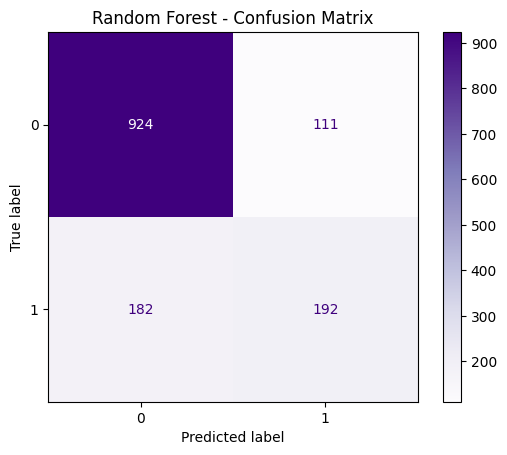

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    random_forest,
    X_test,
    y_test,
    cmap="Purples"
)

plt.title("Random Forest - Confusion Matrix")
plt.show()

### Interpretation

The Random Forest model correctly classified **924 non-churn customers** and **192 churn customers**.

The model incorrectly predicted **111 non-churn customers** as churn (False Positives) and failed to identify **182 actual churn customers** (False Negatives).

Compared with the Decision Tree model, Random Forest significantly reduced false positive predictions and improved the overall classification performance. However, the Logistic Regression model still achieved a higher recall for churn customers.

## ROC Curve and AUC Score

The ROC curve illustrates the Random Forest model's ability to distinguish between churn and non-churn customers across different classification thresholds.

The Area Under the Curve (AUC) summarizes the overall discriminative performance of the model.

AUC Score: 0.8371


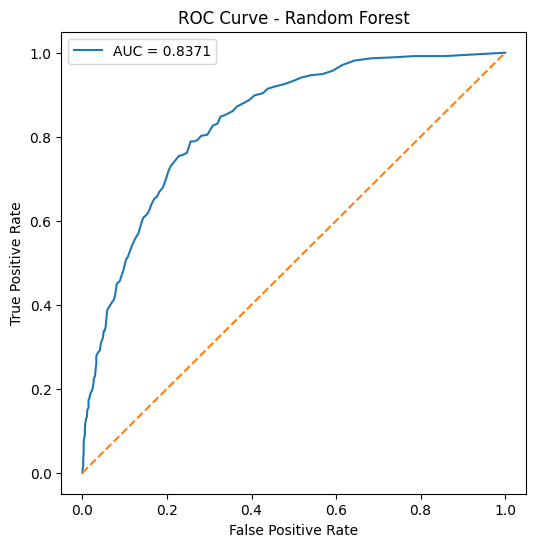

In [30]:
y_prob_forest = random_forest.predict_proba(X_test)[:, 1]

fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_test, y_prob_forest)

auc_forest = roc_auc_score(y_test, y_prob_forest)

print(f"AUC Score: {auc_forest:.4f}")

plt.figure(figsize=(6,6))

plt.plot(
    fpr_forest,
    tpr_forest,
    label=f"AUC = {auc_forest:.4f}"
)

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")

plt.legend()

plt.show()

In [31]:
train_predictions_forest = random_forest.predict(X_train)

train_accuracy_forest = accuracy_score(y_train, train_predictions_forest)
test_accuracy_forest = accuracy_score(y_test, y_pred_forest)

print(f"Training Accuracy : {train_accuracy_forest:.4f}")
print(f"Testing Accuracy  : {test_accuracy_forest:.4f}")

Training Accuracy : 1.0000
Testing Accuracy  : 0.7921


## Overfitting Analysis

The Random Forest model achieved **100% training accuracy**, while its testing accuracy reached **79.21%**.

Although the model still shows signs of overfitting, the gap between training and testing performance is smaller than that of the single Decision Tree model.

This indicates that combining multiple decision trees improves generalization performance and reduces the impact of overfitting.

## Random Forest Summary

The Random Forest model achieved a testing accuracy of **79.21%** and an AUC score of **0.8371**.

Compared with the Decision Tree model, Random Forest significantly improved overall classification performance and reduced the effects of overfitting.

However, the Logistic Regression model still achieved slightly better Accuracy, Recall, F1 Score, and AUC values on this dataset.

Further hyperparameter tuning may improve the performance of the Random Forest model in future experiments.

# Gradient Boosting Classifier

## Objective

A Gradient Boosting model is trained and evaluated to improve churn prediction by sequentially combining multiple weak decision trees. Each new tree focuses on correcting the errors made by the previous trees.

In [32]:
from sklearn.ensemble import GradientBoostingClassifier

## Model Initialization

The Gradient Boosting classifier is initialized using a sequence of weak decision trees. Each tree attempts to correct the prediction errors made by the previous trees.

In [33]:
gradient_boosting = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

print(gradient_boosting)

GradientBoostingClassifier(random_state=42)


## Model Training

The Gradient Boosting model is trained using the processed training dataset. During training, each new decision tree focuses on correcting the prediction errors made by the previous trees.

In [34]:
gradient_boosting.fit(X_train, y_train)

print("Gradient Boosting training completed successfully!")

Gradient Boosting training completed successfully!


## Making Predictions

The trained Gradient Boosting model is used to predict customer churn on the testing dataset.

In [35]:
y_pred_gb = gradient_boosting.predict(X_test)

print("Number of predictions:", len(y_pred_gb))
print(y_pred_gb[:10])

Number of predictions: 1409
[0 1 0 0 0 1 1 0 0 0]


## Model Evaluation

The Gradient Boosting model is evaluated using standard classification metrics, including accuracy, precision, recall, and F1 score.

In [36]:
accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb)
recall_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)

print(f"Accuracy : {accuracy_gb:.4f}")
print(f"Precision: {precision_gb:.4f}")
print(f"Recall   : {recall_gb:.4f}")
print(f"F1 Score : {f1_gb:.4f}")

Accuracy : 0.8013
Precision: 0.6526
Recall   : 0.5374
F1 Score : 0.5894


## Classification Report

A detailed classification report is generated to evaluate the Gradient Boosting model for each class separately.

In [37]:
print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.54      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



## Confusion Matrix

The confusion matrix summarizes the number of correct and incorrect predictions made by the Gradient Boosting model.

In [38]:
cm_gb = confusion_matrix(y_test, y_pred_gb)

print(cm_gb)

[[928 107]
 [173 201]]


## Confusion Matrix Visualization

The confusion matrix is visualized to better understand the distribution of correct and incorrect predictions made by the Gradient Boosting model.

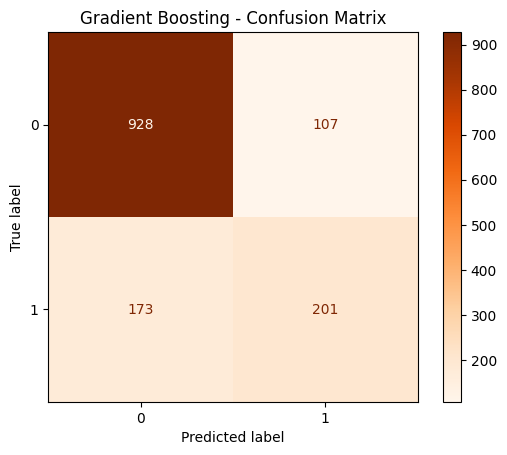

In [39]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    gradient_boosting,
    X_test,
    y_test,
    cmap="Oranges"
)

plt.title("Gradient Boosting - Confusion Matrix")
plt.show()

### Interpretation

The Gradient Boosting model correctly classified **928 non-churn customers** and **201 churn customers**.

The model incorrectly predicted **107 non-churn customers** as churn (False Positives) and failed to identify **173 actual churn customers** (False Negatives).

Compared with the Decision Tree and Random Forest models, Gradient Boosting reduced the number of false positive predictions and improved the identification of churn customers. However, the Logistic Regression model still detected more actual churn customers.

## ROC Curve and AUC Score

The ROC curve illustrates the Gradient Boosting model's ability to distinguish between churn and non-churn customers across different classification thresholds.

The Area Under the Curve (AUC) summarizes the overall discriminative performance of the model.

AUC Score: 0.8510


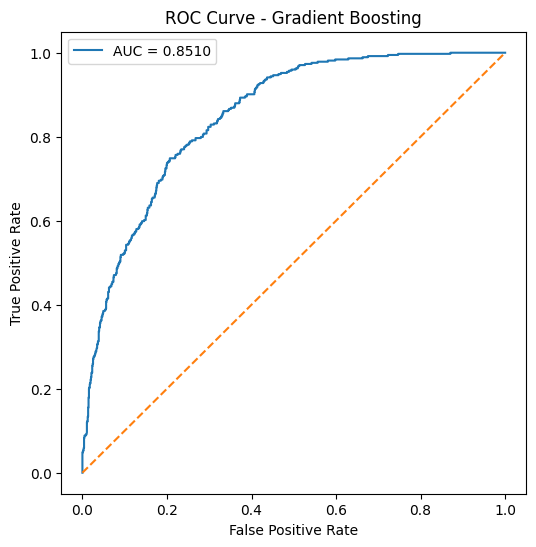

In [40]:
y_prob_gb = gradient_boosting.predict_proba(X_test)[:, 1]

fpr_gb, tpr_gb, thresholds_gb = roc_curve(y_test, y_prob_gb)

auc_gb = roc_auc_score(y_test, y_prob_gb)

print(f"AUC Score: {auc_gb:.4f}")

plt.figure(figsize=(6,6))

plt.plot(
    fpr_gb,
    tpr_gb,
    label=f"AUC = {auc_gb:.4f}"
)

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gradient Boosting")

plt.legend()

plt.show()

## Overfitting Analysis

The training and testing accuracies are compared to determine whether the Gradient Boosting model has overfitted the training data.

In [41]:
train_predictions_gb = gradient_boosting.predict(X_train)

train_accuracy_gb = accuracy_score(y_train, train_predictions_gb)
test_accuracy_gb = accuracy_score(y_test, y_pred_gb)

print(f"Training Accuracy : {train_accuracy_gb:.4f}")
print(f"Testing Accuracy  : {test_accuracy_gb:.4f}")

Training Accuracy : 0.8371
Testing Accuracy  : 0.8013


## Overfitting Analysis

The Gradient Boosting model achieved a **training accuracy of 83.71%** and a **testing accuracy of 80.13%**.

The small difference between training and testing performance indicates that the model generalizes well to unseen data and does not suffer from severe overfitting.

Compared with the Decision Tree and Random Forest models, Gradient Boosting provides a better balance between learning the training data and maintaining strong predictive performance on the testing data.

## Gradient Boosting Summary

The Gradient Boosting model achieved a testing accuracy of **80.13%** and an AUC score of **0.8510**.

Compared with the Decision Tree and Random Forest models, Gradient Boosting produced better overall classification performance and demonstrated excellent generalization ability with only a small gap between training and testing accuracy.

Although Logistic Regression achieved a slightly higher Accuracy, Recall, and F1 Score, Gradient Boosting obtained the highest AUC score among all evaluated models, indicating superior class discrimination across different decision thresholds.

The model is considered one of the strongest candidates for customer churn prediction in this project.